In [ ]:
import pandas as pd
from pathlib import Path
import torch
import warnings
warnings.filterwarnings('ignore')
from DataAnalysisModule import JBImageProcessor, DataAnalysisModule

##### بررسی مختصات تصویر ب کادر کشیدن (مشخص نبود کادر ها دقیقا به کجای تصویر اشاره میکنند و تصویر نمایش داده شده بزرگ بود)

In [30]:
import cv2


# متغیر برای ذخیره مختصات کلیک
start_point = None
end_point = None

# این تابع برای ثبت مختصات کلیک کاربر است
def click_and_crop(event, x, y, flags, param):
    global start_point, end_point

    if event == cv2.EVENT_LBUTTONDOWN:  # کلیک چپ موس
        start_point = (x, y)  # ذخیره نقطه شروع

    elif event == cv2.EVENT_LBUTTONUP:  # وقتی موس رها می‌شود
        end_point = (x, y)  # ذخیره نقطه انتها

        # کشیدن مستطیل برای نمایش ناحیه انتخابی
        cv2.rectangle(image, start_point, end_point, (0, 255, 0), 2)
        cv2.imshow("Image", image)


image = cv2.imread('C:\\Users\\fatemeh.feizbakhsh\\Desktop\\JBWiriingDiagramPhotos\\AB-EIN-DA-WP20-8220-D3 (JB wiring)_Page_15.jpg')

if image is None:
    print("تصویر بارگذاری نشد. لطفاً مسیر فایل را بررسی کنید.")
else:
    cv2.imshow("Image", image)
    cv2.setMouseCallback("Image", click_and_crop)
    cv2.waitKey(0)
    cv2.destroyAllWindows()

# نمایش تصویر و ثبت کلیک‌ها
cv2.imshow("Image", image)
cv2.setMouseCallback("Image", click_and_crop)

cv2.waitKey(0)
cv2.destroyAllWindows()

# نمایش مختصات نقاط انتخابی
if start_point and end_point:
    print(f"نقطه شروع: {start_point}")
    print(f"نقطه انتها: {end_point}")


نقطه شروع: (671, 1036)
نقطه انتها: (734, 1039)


##### برش زدن تصاویر با استفاده از Wiring Spliter script (مختصات Tag ها در تمام تصاویر یکسان نبود و برش تمام تصاویر از ناحیه Tag ها ممکن نبود)


Processing wiring_diagram1.jpg...
Successfully processed: wiring_diagram1.jpg
Standardized image saved as: output\STD_wiring_diagram1.jpg
JB section saved as: output\JB_SECTION_wiring_diagram1.jpg
Tag sections saved as:
- output\TAG_SECTION_1_wiring_diagram1.jpg
- output\TAG_SECTION_2_wiring_diagram1.jpg

JB Section:


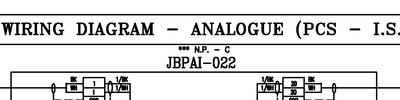


Tag Sections:

Tag section from output\TAG_SECTION_1_wiring_diagram1.jpg:


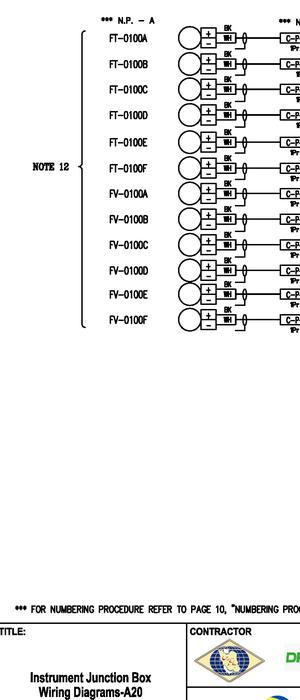


Tag section from output\TAG_SECTION_2_wiring_diagram1.jpg:


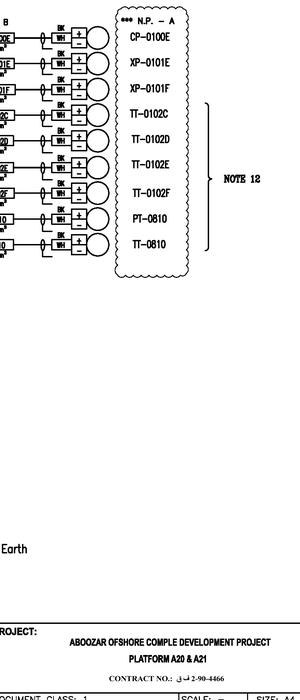


Processing wiring_diagram2.jpg...
Successfully processed: wiring_diagram2.jpg
Standardized image saved as: output\STD_wiring_diagram2.jpg
JB section saved as: output\JB_SECTION_wiring_diagram2.jpg
Tag sections saved as:
- output\TAG_SECTION_1_wiring_diagram2.jpg
- output\TAG_SECTION_2_wiring_diagram2.jpg

JB Section:


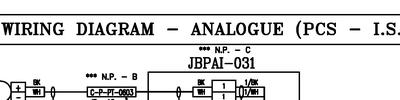


Tag Sections:

Tag section from output\TAG_SECTION_1_wiring_diagram2.jpg:


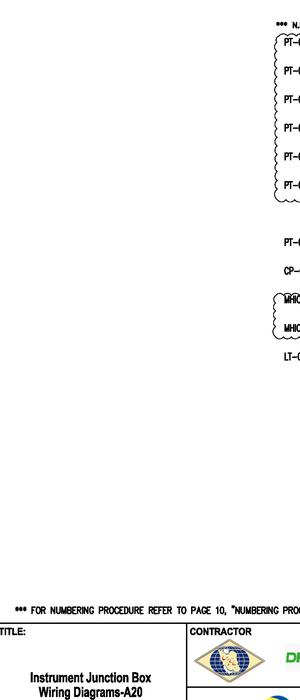


Tag section from output\TAG_SECTION_2_wiring_diagram2.jpg:


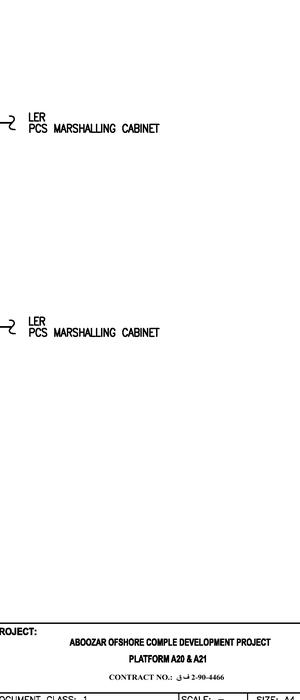


Final Database contents:

JB: output\JB_SECTION_wiring_diagram1.jpg
Tags:
- output\TAG_SECTION_1_wiring_diagram1.jpg
- output\TAG_SECTION_2_wiring_diagram1.jpg

JB: output\JB_SECTION_wiring_diagram2.jpg
Tags:
- output\TAG_SECTION_1_wiring_diagram2.jpg
- output\TAG_SECTION_2_wiring_diagram2.jpg


In [1]:
# Import the ImageSplitter class
from wiring_splitter import ImageSplitter

# Create an instance of ImageSplitter
splitter = ImageSplitter()

# List of images to process
image_paths = [
    "wiring_diagram1.jpg",
    "wiring_diagram2.jpg"
]

# Process each image
for image_path in image_paths:
    print(f"\nProcessing {image_path}...")
    result = splitter.process_image(image_path)
    
    if result:
        # Display the results
        from IPython.display import Image, display
        
        print("\nJB Section:")
        display(Image(result['jb_path']))
        
        print("\nTag Sections:")
        for path in result['tag_paths']:
            print(f"\nTag section from {path}:")
            display(Image(path))

# Display final database contents
database = splitter.get_database()
print("\nFinal Database contents:")
for jb_key, sections in database.items():
    print(f"\nJB: {jb_key}")
    print("Tags:")
    for tag in sections.tags:
        print(f"- {tag}")

##### مشخص کردن Address کتابخانه pytesseract

In [4]:
import pytesseract

# مسیر نصب Tesseract را مشخص کنید (ویندوز)
pytesseract.pytesseract.tesseract_cmd = r"C:\Program Files\Tesseract-OCR\tesseract.exe"

# تست اجرای Tesseract
print(pytesseract.get_tesseract_version())


5.5.0.20241111


##### بدست اوردن تمام متن موجود در تصویر با استفاده از cv2

In [8]:
import cv2
import numpy as np
from PIL import Image


# Load image using OpenCV
image_cv = cv2.imread(image_path)

# Convert to grayscale
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

# Apply adaptive thresholding for better contrast
processed = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
                                  cv2.THRESH_BINARY, 11, 2)

# Save the processed image temporarily
processed_image_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/processed_wiring_diagram.jpg"
cv2.imwrite(processed_image_path, processed)

# Apply OCR again on the processed image
processed_text = pytesseract.image_to_string(Image.open(processed_image_path))

# Show a snippet of the improved extracted text
processed_text[:10000]  # Show only the first 1000 characters for preview


'WIRING DIAGRAM — ANALOGUE (PCS = LS.)\n\noe NP. - B = — = - NPS 8 we NPA\n{C-P-FT-0100A f 1_Tf aif} 4 P0100 -—F- © CP-O100E\nPrx.15 ma? ; H sm Prox 15 mm : 7 0\n\nCP-FT-01 z aN C-P=XP-0101 7 t XP-O101E\nPr x15 mm? Prxi5 man? ‘ 7 ¢\n\n= aaeT 1B: af  XP-O101F\nCPHTOIOE a IB: : Tart )~ Tr-01020\nPr.x 15 mae 7 :\n\nC-P-F-O100F IDs ai) é }¢ TI-O102E\n1C-P-FV-O100A : : ; f- S$ TT-0102F\n\nPT-0810\n\n| BK\n“f\nv\nf\\\n\n© Pees am?\n\nL-}—\n@2u: : TERED\n\nPrx15 mnt\n\n"== Plant Earth\n\n19Pr-x 1 mm? [-EP=JEPA-022N)\n12Pr xf mm? b-LP—JEPN-0228\nPCS MARSHALLING CABINET\nPp Pov:\nrrr, tt ‘ABOOZAR OFSHORE COMPLE DEVELOPMENT PROJECT\nD3 }29.Dee.2\'] APPROVED FoR consmaucTiON, | ms. [Ms.[rsi [MAl Nsw | AA | PLATFORM A20 & A24\npz aserserraoen ron oosmucron [saifsa [amc pal Ke [Ax |\n\nfoiferecrssu rn wmrom [sa [sacl al ee | aa | —EN\nHaistanin fafrsenralasve rn comer [or [wuelta(wal ee | ax [DOCUMENT CLASS: 1 ———~=SSC*SCALE: — ‘| SIZE A |\n\nGil ge] 0 p18 OES CAs Sp lomawn|prer|cuece|are] mee | ar

##### تنها متن شناساییی شده JB بود(pattern تعریف شده برای Tag ها اشتباه بود)

In [10]:
import cv2
import numpy as np
import pandas as pd
import pytesseract
import re
from PIL import Image
from tkinter import filedialog

# انتخاب فایل Excel ورودی
excel_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/Tagpattern.xlsx"

# خواندن فایل اکسل
df = pd.read_excel(excel_path)

# استخراج ستون Tagها (فرض: نام ستون "Tag" است)
tag_column_name = "Tag No"  # اینجا نام دقیق ستون را تنظیم کنید
tags = df[tag_column_name].dropna().astype(str).tolist()

# ایجاد الگوی Tag بر اساس داده‌های موجود
tag_pattern = "|".join([re.escape(tag) for tag in tags])  # ساخت یک الگو از لیست تگ‌ها

# مسیر تصویر ورودی را مشخص کنید
image_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/processed_wiring_diagram.jpg"

# پردازش تصویر
image_cv = cv2.imread(image_path)
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)
processed = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# ذخیره تصویر پردازش‌شده موقتاً
processed_image_path = "processed_wiring_diagram.jpg"
cv2.imwrite(processed_image_path, processed)

# اعمال OCR روی تصویر پردازش‌شده
processed_text = pytesseract.image_to_string(Image.open(processed_image_path))

# الگوی JB
jb_pattern = r'JB[A-Z]{2,4}-\d{3}'

# یافتن تمام JBها و Tagهای شناسایی‌شده
jb_matches = re.findall(jb_pattern, processed_text)
tag_matches = re.findall(tag_pattern, processed_text)

# ایجاد دیکشنری JB -> List of Tags
jb_tag_dict = {jb: [] for jb in set(jb_matches)}

for tag in tag_matches:
    for jb in jb_matches:
        if jb in processed_text:  # بررسی وجود JB در همان بخش متن
            jb_tag_dict[jb].append(tag)

# نمایش خروجی
for jb, tags in jb_tag_dict.items():
    print(f"{jb}: {tags}")

# ذخیره دیکشنری در یک فایل خروجی
output_df = pd.DataFrame([(jb, ", ".join(tags)) for jb, tags in jb_tag_dict.items()], columns=["JB", "Tags"])
output_df.to_excel("JB_Tag_Mapping.xlsx", index=False)
print("داده‌ها در فایل JB_Tag_Mapping.xlsx ذخیره شدند.")


داده‌ها در فایل JB_Tag_Mapping.xlsx ذخیره شدند.


##### ابتدا در custom_config از --psm 6 استفاده می شد که غلط بئد و برای تصاویری که متن به صورت خطی در ان قرار دارد کاربرد داشت سپس از  --psm 11 استفاده شد که مخصوص متون پراکنده در تصویر است در اینجا الگو تعریف شده برای JB پاسخگو نمی باشد 

In [19]:
import cv2
import numpy as np
import pandas as pd
import pytesseract
import re
from PIL import Image

# 📂 مسیر فایل اکسل
excel_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/Tagpattern.xlsx"
df = pd.read_excel(excel_path)

# 🔍 تعیین الگوی Regex برای Tag و JB
tag_pattern = r'\b(?!JB\b)[A-Z]{2,7}-\d{4}[A-Z]?'
jb_pattern = r'JB[A-Z]+-\d{3,4}'  # اصلاح شده برای پشتیبانی از 3 یا 4 رقم

# 📷 مسیر تصویر
image_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/wiring_diagram2.jpg"


# 🖼 پردازش تصویر برای بهبود خوانایی
image_cv = cv2.imread(image_path)
gray = cv2.cvtColor(image_cv, cv2.COLOR_BGR2GRAY)

# 🎯 افزایش کنتراست
clahe = cv2.createCLAHE(clipLimit=3.0, tileGridSize=(8, 8))
contrast = clahe.apply(gray)

# 🔍 استفاده از Threshold پیشرفته
_, binary = cv2.threshold(contrast, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)

# 📷 ذخیره تصویر پردازش‌شده جدید
processed_image_path = "processed_output.jpg"
cv2.imwrite(processed_image_path, binary)

custom_config = r'--oem 3 --psm 11 -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789.-'

# 📝 استخراج متن با OCR
 # بهبود تشخیص متن‌های چیده‌شده در جدول
processed_text = pytesseract.image_to_string(Image.open(processed_image_path), config=custom_config)

# 📄 ذخیره متن OCR برای بررسی
with open("ocr_output.txt", "w", encoding="utf-8") as file:
    file.write(processed_text)

# 🔍 یافتن JB و Tag در متن استخراج شده
jb_matches = re.findall(jb_pattern, processed_text)
tag_matches = re.findall(tag_pattern, processed_text)

# نمایش نتایج در کنسول
print("\n🔎 **JBهای شناسایی شده:**", jb_matches)
print("\n🔎 **Tagهای شناسایی شده:**", tag_matches)

# 📌 تطبیق JBها با تگ‌های نزدیک به آن‌ها
jb_tag_dict = {}
lines = processed_text.split("\n")  # تقسیم متن به خطوط

for i, line in enumerate(lines):
    jb_found = re.findall(jb_pattern, line)
    tags_found = re.findall(tag_pattern, line)

    for jb in jb_found:
        if jb not in jb_tag_dict:
            jb_tag_dict[jb] = []

        # بررسی تگ‌های همان خط + خطوط بالا و پایین
        for offset in [-1, 0, 1]:
            if 0 <= i + offset < len(lines):
                nearby_tags = re.findall(tag_pattern, lines[i + offset])
                jb_tag_dict[jb].extend(nearby_tags)

# حذف تگ‌های تکراری
for jb in jb_tag_dict:
    jb_tag_dict[jb] = list(set(jb_tag_dict[jb]))

# 📝 نمایش نتایج
print("\n📊 **JB -> Tag Mapping:**")
for jb, tags in jb_tag_dict.items():
    print(f"{jb}: {tags}")

# 📥 ذخیره در اکسل
output_df = pd.DataFrame([(jb, ", ".join(tags)) for jb, tags in jb_tag_dict.items()], columns=["JB", "Tags"])
output_filename = "JB_Tag_Mapping.xlsx"
output_df.to_excel(output_filename, index=False)

print(f"\n✅ داده‌ها در فایل {output_filename} ذخیره شدند.")



🔎 **JBهای شناسایی شده:** []

🔎 **Tagهای شناسایی شده:** ['PT-0603', 'PT-0625', 'PT-0623', 'PT-0802', 'PT-0802', 'PT-0740', 'PT-0740', 'PT-0741', 'PT-0741', 'PT-0742', 'PT-0742', 'PT-0730', 'PT-0730', 'CP-0621', 'CP-0621', 'MHIC-0604', 'MHNC-0622', 'LT-0720']

📊 **JB -> Tag Mapping:**

✅ داده‌ها در فایل JB_Tag_Mapping.xlsx ذخیره شدند.


##### در اینجا برای شناسایی JB , Tag ها از وجود حروف در یک کلمه استفاده شد که باعث یافت راحت JB درون Diagram شد ولی به دلیل استفاده از  --psm 6 Tag ها به خوبی شناسایی نمی شوند

In [ ]:

import cv2
import pytesseract
import numpy as np
from PIL import Image
import pandas as pd
import re


# بارگذاری تصویر
image_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/wiring_diagram1.jpg"
image = cv2.imread(image_path)

# تبدیل به خاکستری
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# افزایش کنتراست و کاهش نویز
gray = cv2.GaussianBlur(gray, (5, 5), 0)
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# ذخیره تصویر پردازش‌شده موقتاً
processed_image_path = "C:/Users/fatemeh.feizbakhsh/Desktop/JBDtection/processed_wiring_diagram.jpg"
cv2.imwrite(processed_image_path, gray)

# استفاده از OCR برای استخراج متن
custom_oem_psm_config = r'--oem 3 --psm 6'  # تنظیمات بهینه Tesseract
extracted_text = pytesseract.image_to_string(gray, config=custom_oem_psm_config)

# جداسازی خطوط متنی
lines = extracted_text.split("\n")

jb_identifiers = set()

for line in lines:
    words = line.split()
    for word in words:
        if "FT" in word or "FV" in word or "TT-" in word or "PT" in word or "CP-" in word or "XP-" in word:
            tags.add(word)
        elif "JB" in word:
            jb_identifiers.add(word)

# نمایش خروجی
jb_identifiers

{'JBPAI—022'}

In [ ]:
import os
print(os.listdir('C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments'))


['IODB.xlsx', 'JB_Tag_Mapping.xlsx', 'ocr_output.txt', 'output', 'output.xlsx', 'PDF.pdf', 'processed_output.jpg', 'processed_wiring_diagram.jpg', 'Read Me.txt', 'Tagpattern.xlsx', 'wiring_diagram1.jpg', 'wiring_diagram2.jpg', 'wiring_diagram3.jpg', 'wiring_diagram4.jpg']


##### در انجا ابتدا تصویر مانند کد قبلی به طور کلی پردازش می شود و JB از ان استخراج می شود سپس تصویر را به دو قسمت تقسیم میشود و هر بخش را جداگانه برای Tag ها detect میشود 

In [35]:
import cv2
import pytesseract
import numpy as np
from PIL import Image
import pandas as pd
import re

# تنظیم مسیر Tesseract (در صورت نیاز)
pytesseract.pytesseract.tesseract_cmd = r'C:\Program Files\Tesseract-OCR\tesseract.exe'
image_path = r"C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments\wiring_diagram4.jpg"
image = cv2.imread(image_path)

# تبدیل به خاکستری
gray = cv2.cvtColor(image, cv2.COLOR_BGR2GRAY)

# افزایش کنتراست و کاهش نویز
gray = cv2.GaussianBlur(gray, (5, 5), 0)
gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 11, 2)

# ذخیره تصویر پردازش‌شده موقتاً
processed_image_path = r"C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments\processed_wiring_diagram.jpg"
cv2.imwrite(processed_image_path, gray)

# استفاده از OCR برای استخراج متن
custom_oem_psm_config = r'--oem 3 --psm 6'  # تنظیمات بهینه Tesseract
extracted_text = pytesseract.image_to_string(gray, config=custom_oem_psm_config)

# جداسازی خطوط متنی
lines = extracted_text.split("\n")

jb_identifiers = set()

for line in lines:
    words = line.split()
    for word in words:
        # تشخیص JB در ابتدای کلمه
        if word.upper().startswith("JB"):
            jb_identifiers.add(word.upper())

def preprocess_image(image_path):
    # خواندن تصویر و تنظیم DPI
    img = Image.open(image_path)
    img = img.convert('RGB') 
    open_cv_image = np.array(img)
    
    # تبدیل به خاکستری
    gray = cv2.cvtColor(open_cv_image, cv2.COLOR_BGR2GRAY)
    
    # افزایش وضوح با افزایش سایز
    scale_factor = 2
    gray = cv2.resize(gray, None, fx=scale_factor, fy=scale_factor, interpolation=cv2.INTER_CUBIC)
    
    # کاهش نویز و افزایش کنتراست
    gray = cv2.medianBlur(gray, 3)
    gray = cv2.GaussianBlur(gray, (3, 3), 0)
    gray = cv2.adaptiveThreshold(gray, 255, cv2.ADAPTIVE_THRESH_GAUSSIAN_C, cv2.THRESH_BINARY, 31, 2)
    
    # عملیات مورفولوژیک برای بستن فاصله‌ها
    kernel = np.ones((2, 2), np.uint8)
    gray = cv2.morphologyEx(gray, cv2.MORPH_CLOSE, kernel)
    
    return gray

# پردازش تصویر
image_path = r"C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments\wiring_diagram4.jpg"
processed_image = preprocess_image(image_path)

# تنظیمات پیشرفته Tesseract
custom_config = r'''
--oem 3 
--psm 11 
-c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456789-.
-c preserve_interword_spaces=1
'''

# استخراج داده با اطلاعات موقعیت و اطمینان
data = pytesseract.image_to_data(
    processed_image,
    config=custom_config,
    output_type=pytesseract.Output.DATAFRAME
)

# فیلتر نتایج با حداقل اطمینان 60%
filtered_data = data[(data.conf > 10) & (data.text.notnull())]
text_blocks = filtered_data[['text', 'left', 'top', 'width', 'height']]

# الگوهای پیشرفته برای شناسایی
tag_pattern = r'''
\b
(?:FT|FV|TT|PT|CP|XP|EHSDI|LAHSD)  # پیشوندهای رایج
[-.]?                              # جداکننده اختیاری
\d{2,4}                            # حداقل ۲ تا ۴ رقم
(?:[A-Z]{1,2}\d*)?                 # پسوند اختیاری حروف و اعداد
\b
'''

jb_pattern = r'''
\b
JB                      # پیشوند JB
[A-Z]*                  # بخش حروف اختیاری
[-_]?                   # جداکننده اختیاری
\d{2,6}                 # بخش عددی
(?:[-_/]\w+)?           # پسوند اختیاری
\b
'''

# استخراج تگ‌ها و مختصات آن‌ها
tags = set()
tag_coordinates = []  # لیست برای ذخیره مختصات تگ‌ها

for idx, row in text_blocks.iterrows():
    word = str(row['text']).strip()
    
    # بررسی و حذف "-P-" از ابتدای تگ
    if word.upper().startswith("-P-"):
        word = word.upper().replace("-P-", "", 1)
    if word.upper().startswith("C-P-"):
        word = word.upper().replace("C-P-", "", 1)
    
    # بررسی الگوی تگ
    if re.search(tag_pattern, word, re.VERBOSE | re.IGNORECASE):
        tags.add(word.upper())
        # ذخیره مختصات تگ
        tag_coordinates.append({
            'tag': word.upper(),
            'left': row['left'],
            'top': row['top'],
            'width': row['width'],
            'height': row['height']
        })

# نمایش نتایج اولیه
print("تگ‌های شناسایی شده (اولیه):")
for tag in sorted(tags):
    print(f"• {tag}")

print("\nشناسه‌های JB:")
for jb in sorted(jb_identifiers):
    print(f"• {jb}")

def detect_columns_and_find_new_tags(image, tag_coordinates, column_threshold=50):
    """
    Enhanced column detection and tag finding with improved processing techniques.
    
    Args:
        image: numpy.ndarray - The preprocessed image
        tag_coordinates: list - List of dictionaries containing tag coordinates
        column_threshold: int - Threshold for column detection
    
    Returns:
        set - New tags found during column analysis
    """
    height, width = image.shape
    columns = {}
    new_tags = set()
    
    # 1. Improved column detection
    x_coordinates = [coord['left'] for coord in tag_coordinates]
    if x_coordinates:
        x_coordinates.sort()
        
        # Dynamic column width based on actual tag positions
        avg_tag_width = sum(coord['width'] for coord in tag_coordinates) / len(tag_coordinates)
        column_threshold = max(int(avg_tag_width * 1.5), column_threshold)
    
    # 2. Group tags into columns with dynamic thresholds
    for tag_info in tag_coordinates:
        tag = tag_info['tag']
        left = tag_info['left']
        
        column_found = False
        for col_left in columns:
            if abs(left - col_left) <= column_threshold:
                columns[col_left].append(tag_info)
                column_found = True
                break
        
        if not column_found:
            columns[left] = [tag_info]
    
    # 3. Enhanced column processing
    for col_left, col_tags in columns.items():
        # Calculate column boundaries based on actual tag positions
        min_x = min(tag['left'] for tag in col_tags)
        max_x = max(tag['left'] + tag['width'] for tag in col_tags)
        
        # Add padding to ensure we capture full tags
        padding = int(column_threshold * 0.5)
        col_start = max(0, min_x - padding)
        col_end = min(width, max_x + padding)
        
        # Extract and process column region
        column_image = image[:, col_start:col_end]
        
        # Apply additional preprocessing to column image
        column_image = cv2.GaussianBlur(column_image, (3, 3), 0)
        column_image = cv2.adaptiveThreshold(
            column_image, 
            255,
            cv2.ADAPTIVE_THRESH_GAUSSIAN_C,
            cv2.THRESH_BINARY,
            21,
            5
        )
        
        # Multiple OCR passes with different configurations
        ocr_configs = [
            r'--oem 3 --psm 6',  # Assume uniform block of text
            r'--oem 3 --psm 11',  # Sparse text with OSD
            r'--oem 3 --psm 12'   # Sparse text without OSD
        ]
        
        for config in ocr_configs:
            column_text = pytesseract.image_to_string(
                column_image,
                config=config + r' -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456-'
            )
            
            # Process extracted text
            for line in column_text.split('\n'):
                words = line.strip().split()
                for word in words:
                    # Clean and normalize the word
                    word = re.sub(r'^[-CP\s]+', '', word.upper())
                    
                    # Extended tag pattern matching
                    tag_patterns = [
                        r'\b(?:FT|FV|TT|PT|CP|XP|EHSDI|LAHSD)[-.]?\d{2,4}(?:[A-Z]{1,2}\d*)?\b',
                        r'\b(?:PT|TT|FT|CP|XP)-\d{3,4}[A-Z]?\b',
                        r'\b[A-Z]{2,4}-\d{3,4}[A-Z]?\b'
                    ]
                    
                    for pattern in tag_patterns:
                        if re.search(pattern, word):
                            new_tags.add(word)
                            break
    
    return new_tags

# Update main processing parameters
def main_processing_parameters():
    """Update the main processing parameters for better tag detection."""
    return {
        'column_threshold': 40,  # Reduced for more precise column detection
        'custom_config': r'''--oem 3 
            --psm 11 
            -c tessedit_char_whitelist=ABCDEFGHIJKLMNOPQRSTUVWXYZ0123456-.
            -c preserve_interword_spaces=1
            -c tessedit_do_invert=0
            -c textord_heavy_nr=1
            -c textord_min_linesize=3
        '''.replace('\n', ' '),
        'confidence_threshold': 30  # Lowered confidence threshold to catch more potential tags
    }

# Usage in main code
params = main_processing_parameters()
new_tags = detect_columns_and_find_new_tags(
    processed_image,
    tag_coordinates,
    params['column_threshold']
)
# اضافه کردن تگ‌های جدید به لیست تگ‌ها
tags.update(new_tags)

# نمایش تمام تگ‌ها
print("\nتمام تگ‌های شناسایی شده (شامل تگ‌های جدید):")
for tag in sorted(tags):
    print(f"• {tag}")

تگ‌های شناسایی شده (اولیه):
• CP-0100A
• CP-0100F
• PT-0100F
• PT-0105F
• TT-0100A
• TT-0100E
• TT-0100F

شناسه‌های JB:
• JBPAI-021

تمام تگ‌های شناسایی شده (شامل تگ‌های جدید):
• CP-0100A
• CP-0100F
• PT-0100F
• PT-0105F
• TI-0100F
• TI-0101F
• TI-0102A
• TI-0102B
• TI-0102B-
• TT-0100A
• TT-0100E
• TT-0100F
• TT-0102A
• TT-0102B
• XP-0101A


In [ ]:
             r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\AB-EIN-DA-WP20-8221-D2 WHSC JB Wiring-A20-Modified.pdf',
            r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\AB-KS-EIN-6281-DR-1066-C3.pdf',
            r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\AB-KS-EIN-6281-DR-1067-C3.pdf',
            r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\AB-KS-EIN-6281-DR-1068-C3.pdf',
            r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\AB-KS-EIN-6282-DR-1033-C2.pdf',
            r'C:\Users\fatemeh.feizbakhsh\Desktop\aboozar\IO Assignment for DCS - Platform A20\Source Document\Pages from AB-ROS-EHV-6287-DA-3011-C4.pdf'

##### این بخش برای استفاده از کلاس DataAnalysis module است در ابتدا PDF را دریافت کرده و در یک صفحات ان را در یک Directory به صورت عکس ذخیره کرده و یک اکسل را از ورودی دریافت میکند و با ستون Tag No موجوئد در ان یک الگو برای  پیدا کردن Tag ها ساخته و شروع به انجام عملیات بالا روی تک تک صفحات ان می کند

In [1]:
from DataAnalysisModule import TagJBExtractor
# نمونه استفاده در Jupyter
# مسیر به tesseract در صورت نیاز (اگر در ویندوز هستید)
tesseract_path = r'C:\Program Files\Tesseract-OCR\tesseract.exe'

# مسیرهای فایل
# نمونه استفاده
extractor = TagJBExtractor(tesseract_path)
pdf_paths = [r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0100-IN-DW-2001-D2 (1)1.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0110-IN-DW-2001-D2 (1)2.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0120-IN-DW-2001-D2 (1)3.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0450-IN-DW-2001-D2 (2)4.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0500-IN-DW-2001-D2 (1)5.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0600-IN-DW-2001-D3 (1)6.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0700-IN-DW-2001-D1 (2)7.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0800-IN-DW-2001-D2 (2)8.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0890-IN-DW-2001-D2 (2)9.pdf',
             r'C:\Users\fatemeh.feizbakhsh\Desktop\IO LIST2\NGL-CT-1-0950-IN-DW-2001-D1 (1)10.pdf']  # لیستی از مسیرهای PDF
unmatched_excel_tags, unmatched_pdf_tags = extractor.run(
    pdf_paths=pdf_paths,
    excel_path=r"C:\Users\fatemeh.feizbakhsh\Desktop\IODB clear ver No.4.xlsx",
    output_excel_path=r"C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments\output.xlsx"  
)
# نمایش نتایج
print("\nProcess completed successfully!")

print("\nUnmatched Excel Tags:")
for tag in unmatched_excel_tags:
    print(f"• {tag}")

print("\nUnmatched PDF Tags:")
for tag in unmatched_pdf_tags:
    print(f"• {tag}")

2025-03-01 12:04:30,628 - INFO - Built dynamic tag pattern from 22 prefixes: LDIT|LCV|AIT|UZSO|PDIT|PCV|UZSC|TCV|FCV|PIT|LIT|ASL|AXA|HZSC|TY|UHSH|TIT|UHSL|LA|UY|HCV|FIT
2025-03-01 12:04:30,628 - INFO - Final tag pattern: \b(?:LDIT|LCV|AIT|UZSO|PDIT|PCV|UZSC|TCV|FCV|PIT|LIT|ASL|AXA|HZSC|TY|UHSH|TIT|UHSL|LA|UY|HCV|FIT)[-.]?\d{3}-\d{2,3}[A-Z]?\d*\b
2025-03-01 12:04:30,628 - INFO - Using tag pattern: \b(?:LDIT|LCV|AIT|UZSO|PDIT|PCV|UZSC|TCV|FCV|PIT|LIT|ASL|AXA|HZSC|TY|UHSH|TIT|UHSL|LA|UY|HCV|FIT)[-.]?\d{3}-\d{2,3}[A-Z]?\d*\b
2025-03-01 12:04:30,638 - INFO - Processing 10 PDF files
2025-03-01 12:04:30,638 - INFO - Processing 10 PDF files using 4 processes
2025-03-01 12:25:51,897 - INFO - Processing Excel file: C:\Users\fatemeh.feizbakhsh\Desktop\IODB clear ver No.4.xlsx



Total Statistics:
--------------------------------------------------
Total Tags found: 654
Total JB identifiers found: 227
Total Pages processed: 244


2025-03-01 12:25:55,881 - INFO - Updated Excel saved to: C:\Users\fatemeh.feizbakhsh\Desktop\JBdetectectiondacuments\output.xlsx



Process completed successfully!

Unmatched Excel Tags:
• ASL-120-91
• AXA-120-91
• FCV-120-83
• FCV-810-42
• FCV-810-53
• FCV-810-54
• FCV-890-04
• FCV-890-06
• FIT-120-83
• FIT-120-92
• FIT-700-95
• FIT-700-97
• FIT-810-01A
• FIT-810-30
• FIT-810-56
• FIT-850-04
• FIT-880-02B
• FIT-910-01
• HCV-100-01
• LCV-110-53
• LCV-110-54
• LCV-120-04
• LCV-120-17
• LCV-120-23
• LCV-120-91A
• LCV-120-91B
• LCV-450-13
• LCV-450-18
• LCV-890-33
• LDIT-100-04
• LIT-500-183
• LIT-810-31
• LIT-810-40
• LIT-900-11
• LIT-930-502
• LIT-940-44
• LIT-940-448
• PCV-450-23
• PCV-810-31
• PDIT-100-13
• PDIT-200-59
• PIT-120-40
• PIT-450-23
• PIT-700-633A1
• PIT-850-01
• PIT-890-401S2
• PIT-890-402A
• PIT-900-613
• PIT-940-448
• TCV-450-06
• TIT-120-611
• TIT-450-110
• TIT-700-81
• TIT-810-09
• TIT-810-17
• TIT-810-39
• TIT-850-35
• TIT-900-611
• TIT-940-02
• TIT-940-41
• TY-900-22
• UHSH-120-17A
• UHSH-700-81A
• UHSH-900-03A
• UHSH-900-12A
• UHSH-900-13A
• UHSH-900-21A
• UHSH-900-22A
• UHSH-940-18A
• UHSH-94